In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Load the 2 files: the master file with all the outlier flags and the original dataset
# Original dataset (assuming it's in the same order as the master file)
df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
X = df.drop(columns=['sii'])
num_cols = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)


df_master = pd.read_csv('./Outliers/outliers_matrix.csv').set_index('row_id')

# 2. Identify columns that contain outlier flags (assuming they start with 'outlier_')
outlier_cols = [c for c in df_master.columns if c.startswith('outlier_')]

# 3. Calculate the mode for each row
# In a binary context (0/1), the mode is 1 if there are more 1s than 0s
# We use the .mode() method from pandas. If there's a tie, it returns both,

df_master['majority_outlier'] = df_master[outlier_cols].mode(axis=1)[0].astype(int)

# 4. Merge with the original dataset X
# If X doesn't have 'row_id' as the index, we assign it now (must be the same order)
if 'row_id' not in X.columns:
    X.index.name = 'row_id'

X_merged = X.join(df_master[['majority_outlier']])

# 5. Remove rows where the majority_outlier is 1
n_before = len(X_merged)
X_clean = X_merged[X_merged['majority_outlier'] == 0].drop(columns=['majority_outlier'])
n_after = len(X_clean)

print(f"Original dataset: {n_before} records")
print(f"Records removed (majority=1): {n_before - n_after}")
print(f"Clean dataset: {n_after} records")

Original dataset: 8460 records
Records removed (majority=1): 621
Clean dataset: 7839 records


## Random projection

In [4]:
from sklearn import random_projection
import matplotlib.pyplot as plt

# since it's random, we can have different results each time we run it. 
# Therefore, we select a random state to have the same results each time 
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=42)
X_rsp = rsp.fit_transform(X)

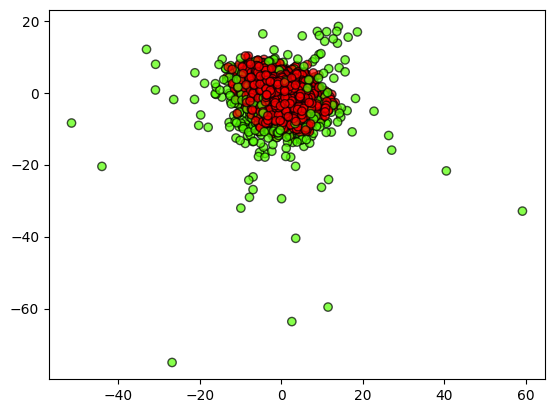

In [5]:
# label the points based on the majority_outlier column
labels = X_merged['majority_outlier'].values
plt.scatter(X_rsp[:, 0], X_rsp[:, 1], c=labels, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

## PCA

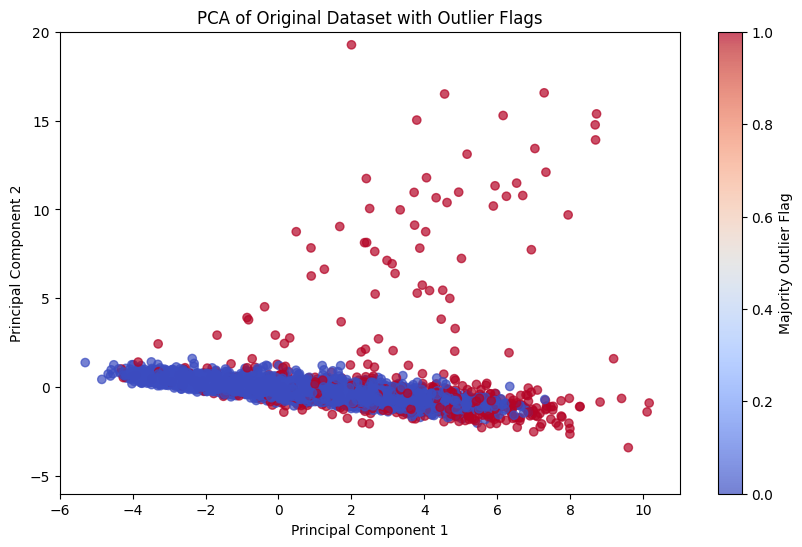

In [ ]:
# PCA on the original dataset with flags on the outliers
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_merged.index)
X_pca['majority_outlier'] = X_merged['majority_outlier']

plt.figure(figsize=(10, 6))
plt.scatter(X_pca['PC1'], X_pca['PC2'], c=X_pca['majority_outlier'], cmap='coolwarm', alpha=0.7)
plt.title('PCA of Original Dataset with Outlier Flags')
plt.xlabel('Principal Component 1')
plt.xlim(-6,11)
plt.ylabel('Principal Component 2')
plt.ylim(-6,20)
plt.colorbar(label='Majority Outlier Flag')
plt.show()


## t-SNE

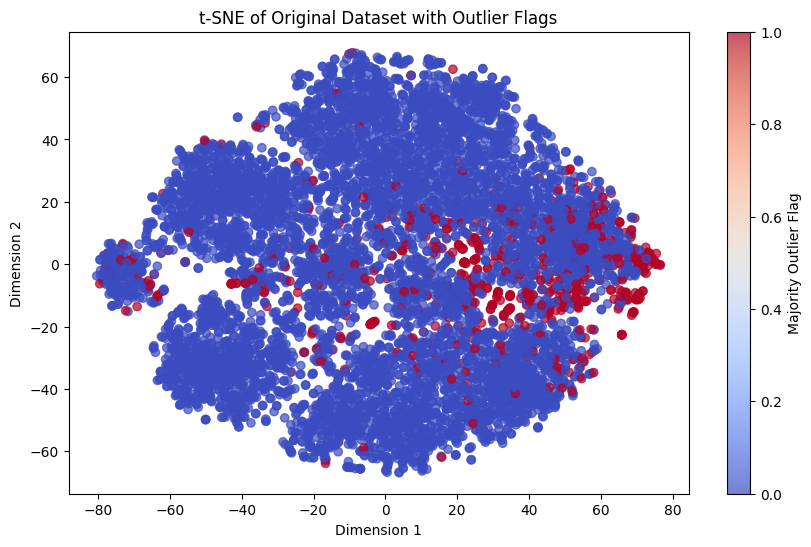

In [3]:
# t-SNE on the original dataset with flags on the outliers
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_merged.drop(columns=['majority_outlier']))
X_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'], index=X_merged.index)
X_tsne['majority_outlier'] = X_merged['majority_outlier']
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne['Dim1'], X_tsne['Dim2'], c=X_tsne['majority_outlier'], cmap='coolwarm', alpha=0.7)
plt.title('t-SNE of Original Dataset with Outlier Flags')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.colorbar(label='Majority Outlier Flag')
plt.show()


In [9]:
# save the clean dataset to a new CSV file
X_clean.to_csv('../dataset/cmi_internet_cleaned.csv', index_label='row_id')